In [3]:
import os 
os.chdir('../../')


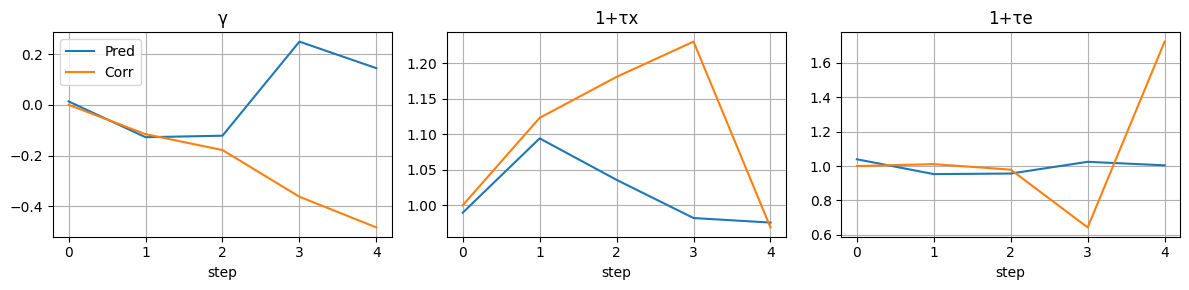

In [77]:
import torch, numpy as np, matplotlib.pyplot as plt

PATH  = 'logs/CFG4.0/0817-3:log-affine semi-pos/step_00002300.pt'
table = torch.load(PATH, map_location='cpu')['solver_state_dict']['param_extractor.table'].float().numpy()  # [S,2,P]
x     = np.arange(table.shape[0])

fig, ax = plt.subplots(1, 3, figsize=(12, 3))
params = [(0, 'γ',     lambda a: a),
          (1, '1+τx',  lambda a: 1.0 + a),
          (2, '1+τe',  lambda a: 1.0 + a)]

for k, (idx, title, f) in enumerate(params):
    ax[k].plot(x, f(table[:, 0, idx]), label='Pred' if k==0 else None)
    ax[k].plot(x, f(table[:, 1, idx]), label='Corr' if k==0 else None)
    ax[k].set_title(title); ax[k].set_xlabel('step')

ax[0].legend()
for a in ax: a.grid(True)

fig.tight_layout(); plt.show()


In [3]:
#!ls "logs/CFG4.0/0817-4:RBF,log-affine semi-pos"
!ls "logs/CFG4.0/0817-5:RBF,semipos,classifier"

events.out.tfevents.1755423320.scpark-X299-WU8.6905.0  step_00000600.pt
events.out.tfevents.1755423420.scpark-X299-WU8.7023.0  step_00000700.pt
step_00000100.pt				       step_00000800.pt
step_00000200.pt				       step_00000900.pt
step_00000300.pt				       step_00001000.pt
step_00000400.pt				       step_00001100.pt
step_00000500.pt				       step_00001200.pt


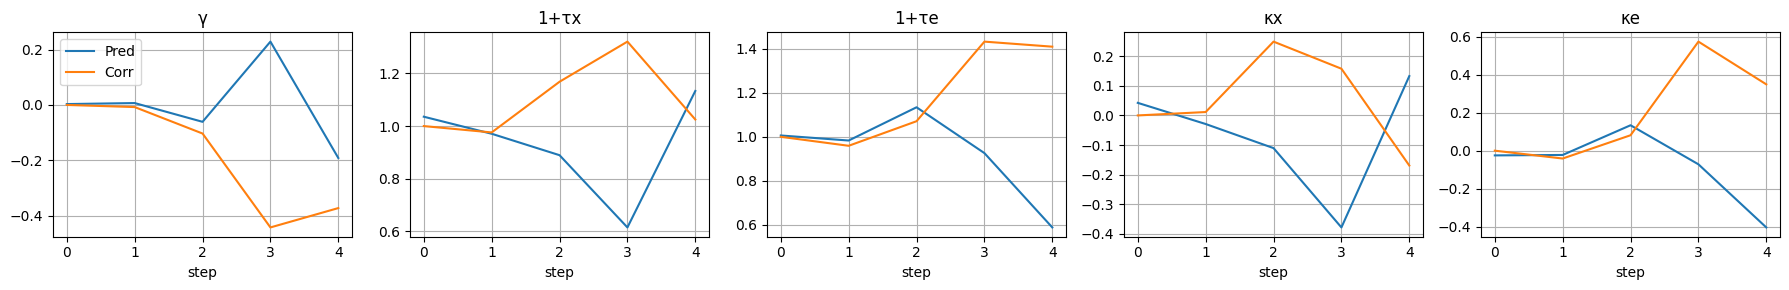

In [4]:
import torch, numpy as np, matplotlib.pyplot as plt

PATH  = 'logs/CFG4.0/0817-5:RBF,semipos,classifier/step_00001200.pt'
tab   = torch.load(PATH, map_location='cpu')['solver_state_dict']['param_extractor.table'].float().numpy()  # [S,2,P]
x     = np.arange(tab.shape[0])

fig, ax = plt.subplots(1, 5, figsize=(18, 3), sharex=True)
params = [
    (0, 'γ',     lambda a: a),
    (1, '1+τx',  lambda a: 1.0 + a),
    (2, '1+τe',  lambda a: 1.0 + a),
    (3, 'κx',    lambda a: a),
    (4, 'κe',    lambda a: a),
]

for k, (idx, title, f) in enumerate(params):
    ax[k].plot(x, f(tab[:, 0, idx]), label='Pred' if k==0 else None)
    ax[k].plot(x, f(tab[:, 1, idx]), label='Corr' if k==0 else None)
    ax[k].set_title(title); ax[k].set_xlabel('step'); ax[k].grid(True)

ax[0].legend(); fig.tight_layout(); plt.show()
# 필요하면 κ 축을 로그스케일로:
# for i in (3,4): ax[i].set_yscale('log')


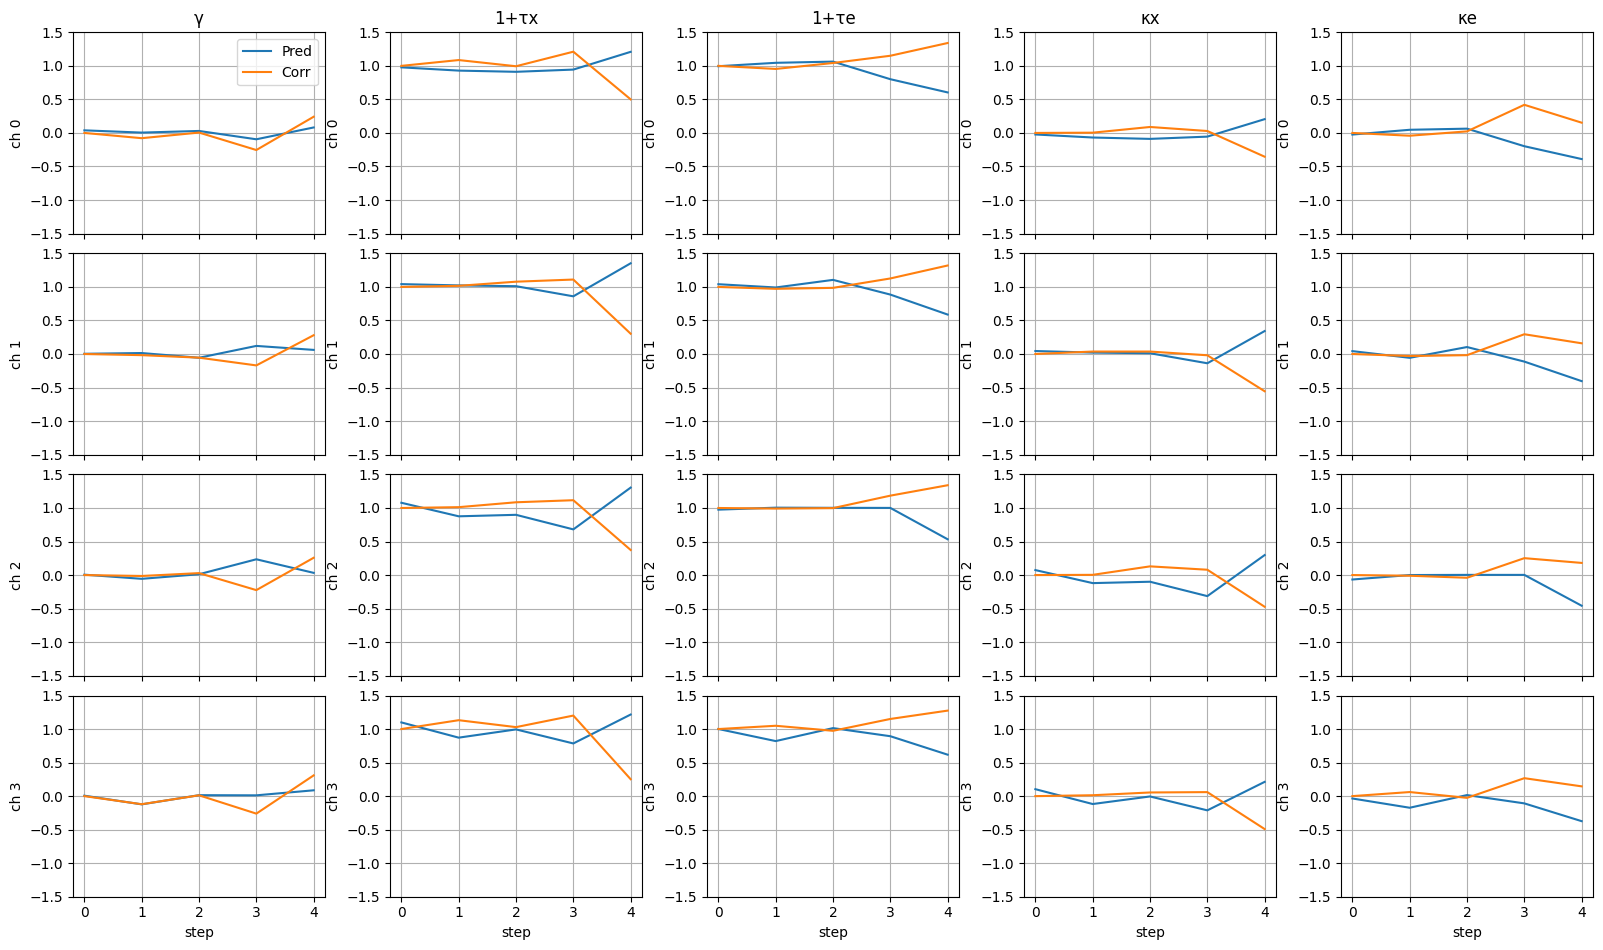

In [22]:
import torch, numpy as np, matplotlib.pyplot as plt

PATH = 'logs/CFG4.0/0817-8:RBF,log-affine semi-pos,4ch/step_00000900.pt'
tab  = torch.load(PATH, map_location='cpu')['solver_state_dict']['param_extractor.table'].float().numpy()  # [S,2,P,C]
S, _, _, C = tab.shape
x = np.arange(S)
params = [(0,'γ',lambda a:a),(1,'1+τx',lambda a:1+a),(2,'1+τe',lambda a:1+a),(3,'κx',lambda a:a),(4,'κe',lambda a:a)]

R = min(4, C)
fig, ax = plt.subplots(R, 5, figsize=(16, 2.4*R), sharex=True, squeeze=False)
for r in range(R):
    for k,(i,t,f) in enumerate(params):
        a = ax[r,k]
        a.plot(x, f(tab[:,0,i,r]), label='Pred' if (r==0 and k==0) else None)
        a.plot(x, f(tab[:,1,i,r]), label='Corr' if (r==0 and k==0) else None)
        a.set_ylim(-1.5, 1.5)
        if r==0: a.set_title(t)
        if r==R-1: a.set_xlabel('step')
        a.set_ylabel(f'ch {r}'); a.grid(True)

ax[0,0].legend(); fig.tight_layout(); plt.show()


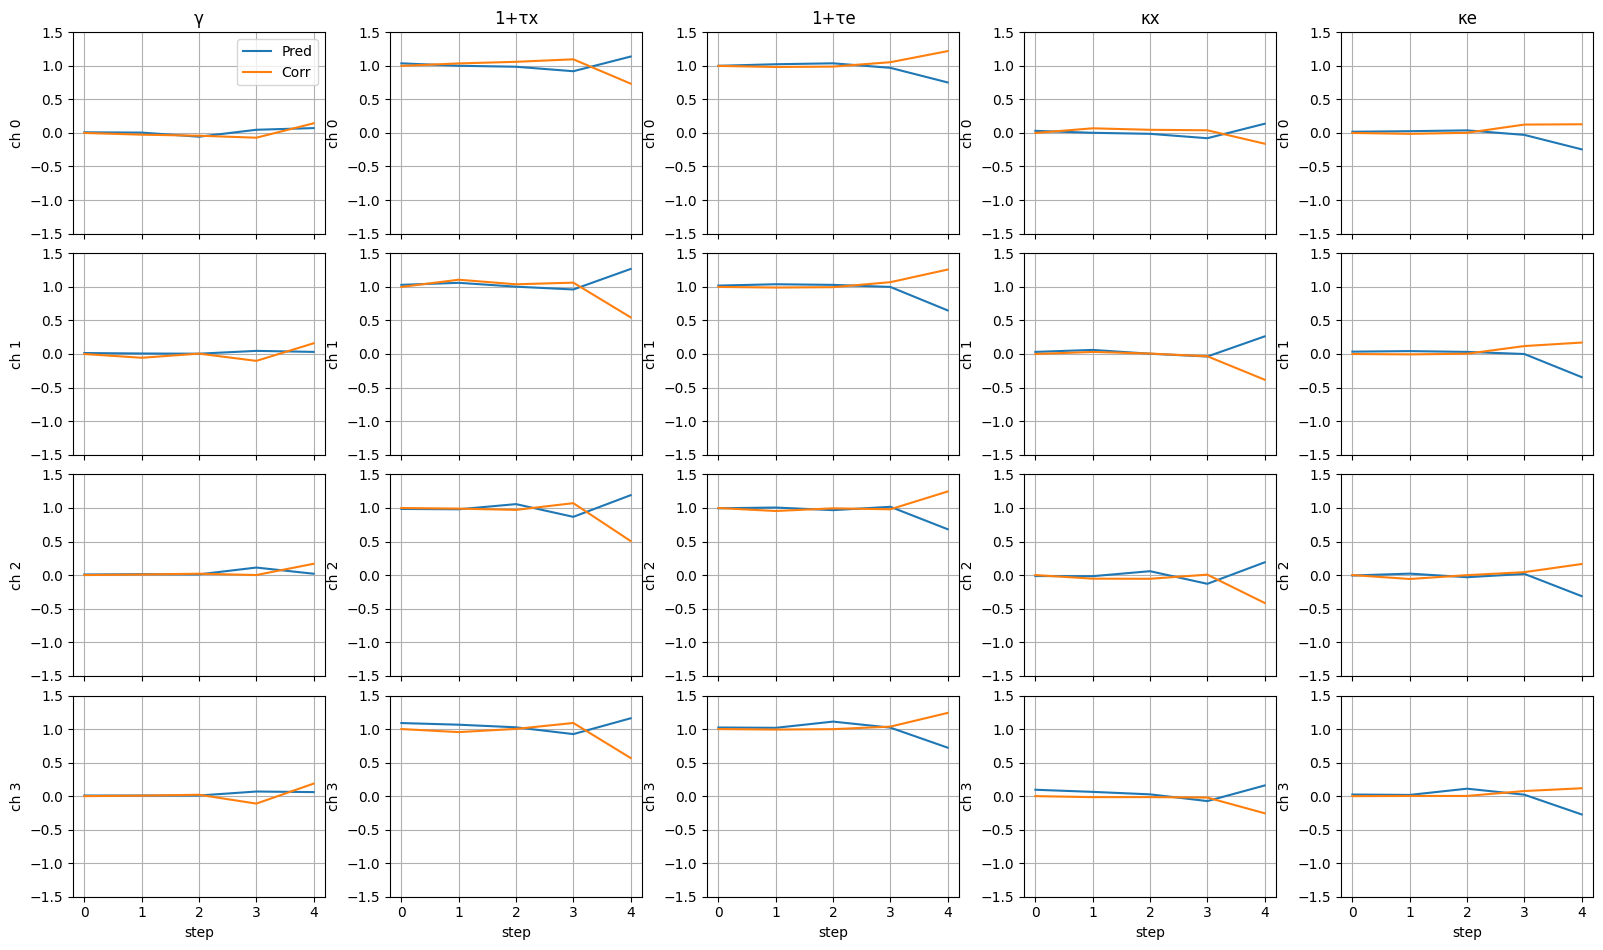

In [23]:
import torch, numpy as np, matplotlib.pyplot as plt

PATH = 'logs/CFG4.0/0817-9:RBF,log-affine semi-pos,4ch/step_00000400.pt'
tab  = torch.load(PATH, map_location='cpu')['solver_state_dict']['param_extractor.table'].float().numpy()  # [S,2,P,C]
S, _, _, C = tab.shape
x = np.arange(S)
params = [(0,'γ',lambda a:a),(1,'1+τx',lambda a:1+a),(2,'1+τe',lambda a:1+a),(3,'κx',lambda a:a),(4,'κe',lambda a:a)]

R = min(4, C)
fig, ax = plt.subplots(R, 5, figsize=(16, 2.4*R), sharex=True, squeeze=False)
for r in range(R):
    for k,(i,t,f) in enumerate(params):
        a = ax[r,k]
        a.plot(x, f(tab[:,0,i,r]), label='Pred' if (r==0 and k==0) else None)
        a.plot(x, f(tab[:,1,i,r]), label='Corr' if (r==0 and k==0) else None)
        a.set_ylim(-1.5, 1.5)
        if r==0: a.set_title(t)
        if r==R-1: a.set_xlabel('step')
        a.set_ylabel(f'ch {r}'); a.grid(True)

ax[0,0].legend(); fig.tight_layout(); plt.show()
